# Input and output formats

`sfsutils` reads variants from a VCF file, a VCF-Zarr store, or a tskit tree sequence through a single streamed site interface, so the same analysis code works for any input format. Writing follows the output file's extension.

The dataset here is one synthetic ARG, provided as a tree sequence together with the VCF and VCF-Zarr store converted from it. Since all three encode the same genotypes, they yield the same spectrum.

In [1]:
setwd("~/PycharmProjects/SFSUtils/")
reticulate::use_condaenv("/Users/janek/miniforge3/envs/sfsutils-dev", required = TRUE)


In [2]:
library(sfsutils)

su <- load_sfsutils()

In [3]:
options(repr.plot.width = 7.2, repr.plot.height = 5.3)

## Three input forms

In [4]:
trees <- "resources/msprime/two_epoch.trees"  # tskit tree sequence (the ARG)
vcf   <- "resources/msprime/two_epoch.vcf"    # VCF written from it
vcz   <- "resources/msprime/two_epoch.vcz"    # VCF-Zarr store converted from the VCF

## Reading

{class}`~sfsutils.parser.Parser` accepts any of the three as its `source` argument and infers the backend from the source. Reading a VCF-Zarr store needs the optional `zarr` package, a tree sequence the optional `tskit` package.

In [5]:
sfs_trees <- su$Parser(source = trees, n = 10, skip_non_polarized = FALSE)$parse()
sfs_vcf   <- su$Parser(source = vcf,   n = 10, skip_non_polarized = FALSE)$parse()
sfs_vcz   <- su$Parser(source = vcz,   n = 10, skip_non_polarized = FALSE)$parse()

INFO:Parser: Using stratification: [all].
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 21767.39it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.
INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file
Parser>Counting sites: 608it [00:00, 4820674.54it/s]
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 24529.04it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.
INFO:Parser: Using stratification: [all].
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 23990.00it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.



In [6]:
# the three spectra are identical
isTRUE(all.equal(sfs_trees$all$to_list(), sfs_vcf$all$to_list())) &&
  isTRUE(all.equal(sfs_vcf$all$to_list(), sfs_vcz$all$to_list()))

[1] TRUE

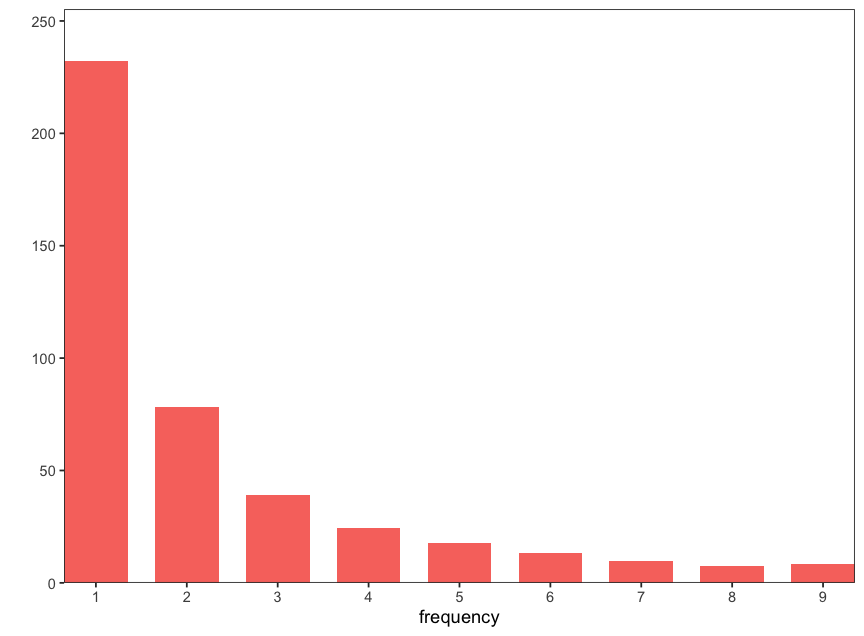

In [7]:
p <- sfs_vcf$all$plot()

## Writing

{class}`~sfsutils.filtration.Filterer` and {class}`~sfsutils.annotation.Annotator` pick the writer from the output file's extension: `.vcf`/`.vcf.gz` for a VCF, `.vcz`/`.zarr` for a VCF-Zarr store, and `.trees` for a tree sequence. A tree sequence can only be written from a tree-sequence input: filtering removes the discarded sites with `delete_sites`, leaving the genealogy intact. A genealogy cannot be reconstructed from genotype data, so writing a `.trees` from a VCF or VCF-Zarr store is rejected.

In [8]:
out <- file.path(tempdir(), "sfsutils-io")
dir.create(out, showWarnings = FALSE)

# a VCF-Zarr store can be written from any input
su$Filterer(source = vcf, output = file.path(out, "snps.vcz"), filtrations = list(su$SNPFiltration()))$filter()

# a VCF is written from a VCF input as before
su$Filterer(source = vcf, output = file.path(out, "snps.vcf"), filtrations = list(su$SNPFiltration()))$filter()

# a tree sequence is written from a tree-sequence input
su$Filterer(source = trees, output = file.path(out, "snps.trees"), filtrations = list(su$SNPFiltration()))$filter()

INFO:Filterer: Start filtering
INFO:Filterer: Loading VCF file
Filterer>Counting sites: 608it [00:00, 4857403.49it/s]
Filterer>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 117620.81it/s]
INFO:SNPFiltration: Filtered out 0 sites.
INFO:Filterer: Filtered out 0 of 608 sites in total.
INFO:Filterer: Start filtering
INFO:Filterer: Loading VCF file
Filterer>Counting sites: 608it [00:00, 5151791.58it/s]
Filterer>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 630130.18it/s]
INFO:SNPFiltration: Filtered out 0 sites.
INFO:Filterer: Filtered out 0 of 608 sites in total.
INFO:Filterer: Start filtering
Filterer>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 102062.63it/s]
INFO:SNPFiltration: Filtered out 0 sites.
INFO:Filterer: Filtered out 0 of 608 sites in total.



The store and tree sequence written above parse back to the same spectrum as the VCF output.

In [9]:
outputs <- c("snps.vcf", "snps.vcz", "snps.trees")
back <- lapply(outputs, function(f)
  su$Parser(source = file.path(out, f), n = 10, skip_non_polarized = FALSE)$parse()$all$to_list())

all(vapply(back, function(v) isTRUE(all.equal(v, back[[1]])), logical(1)))

INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file
Parser>Counting sites: 608it [00:00, 4603135.08it/s]
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 24202.65it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.
INFO:Parser: Using stratification: [all].
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 24713.26it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.
INFO:Parser: Using stratification: [all].
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 22762.98it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.



[1] TRUE